# Discussion – Unsupervised Learning

## Welcome 👋

In this notebook, you will:

- Explore unsupervised structure using combined red and white wine chemistry data  
- Use PCA to understand the main drivers of variation in wine chemical composition  
- Use K-means to identify interpretable wine profile segments  
- Use Gaussian anomaly detection to identify unusual or rare chemical compositions   

---

## Learning Goals

By the end of this discussion, you will be able to:

1. Preprocess mixed categorical and numeric data for unsupervised learning  
2. Apply PCA to reduce dimensionality and interpret principal components economically  
3. Implement K-means clustering and interpret clusters
4. Implement Gaussian anomaly detection and explain what makes observations unusual


In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from scipy.stats import multivariate_normal

random_seed = 42

## Patr 0: Load Data

In [186]:
# Load red and white wine datasets frin UCI
red_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
white_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df_red = pd.read_csv(red_url, sep=';')
df_white = pd.read_csv(white_url, sep=';')

df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

df = pd.concat([df_red, df_white], ignore_index=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## Part 1: Data Exploration

In [127]:
# Numer of observations and raw columns 
print(df.shape)

# Summary statistics for numeric variables
df.drop(columns = 'quality').describe().T

(6497, 13)


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [128]:
# Category shares for two categorical variables
for i in ['quality', 'wine_type']:
    print(df[i].value_counts(normalize=True))

quality
6    0.436509
5    0.329075
7    0.166077
4    0.033246
8    0.029706
3    0.004618
9    0.000770
Name: proportion, dtype: float64
wine_type
white    0.753886
red      0.246114
Name: proportion, dtype: float64


## Part 2: Preprocessing

In [187]:
y = df['quality']
X = df.drop('quality', axis=1)

X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# number of column after encoding
X_scaled.shape[1]

12

## Part 3: PCA

[0.3174498  0.52817876 0.65830372 0.73920691 0.79952468 0.85065306
 0.89535023 0.9372656  0.96663663 0.98803932 0.99798773 1.        ]
Number of components for 80% variance: 6
Number of components for 95% variance: 9


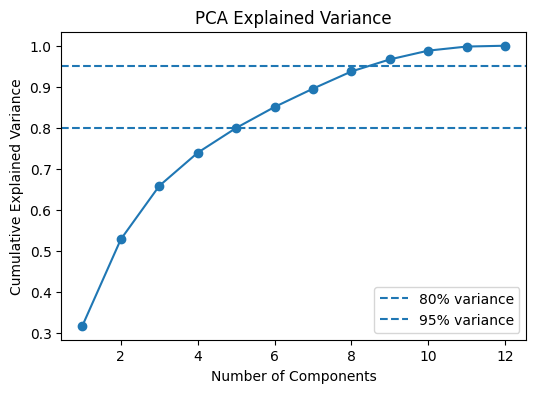

In [139]:
# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)
print(cum_var)

n_80 = np.argmax(cum_var >= 0.80) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1

print(f"Number of components for 80% variance: {n_80}")
print(f"Number of components for 95% variance: {n_95}")

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(y=0.8, linestyle='--', label='80% variance')
plt.axhline(y=0.95, linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.show()

In [140]:
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=[f'PC{i+1}' for i in range(X.shape[1])])
print(loadings)

# Top 5 features for PC1
top5_PC1 = loadings['PC1'].abs().sort_values(ascending=False).head(5)
print("Top 5 features for PC1:")
print(top5_PC1)

# Top 5 features for PC2
top5_PC2 = loadings['PC2'].abs().sort_values(ascending=False).head(5)
print("\nTop 5 features for PC2:")
print(top5_PC2)

                           PC1       PC2       PC3       PC4       PC5  \
fixed acidity        -0.257017  0.272712  0.450202 -0.165191 -0.154164   
volatile acidity     -0.358868  0.034083 -0.286620 -0.217381  0.148704   
citric acid           0.114202  0.207374  0.585204  0.267282 -0.160007   
residual sugar        0.245922  0.397786 -0.172743 -0.165084 -0.356529   
chlorides            -0.295318  0.241181  0.006825  0.237108  0.641026   
free sulfur dioxide   0.345377  0.169419 -0.157171  0.363922  0.172551   
total sulfur dioxide  0.413005  0.191248 -0.126777  0.211991  0.138231   
density              -0.142020  0.561267 -0.161452 -0.074797 -0.294989   
pH                   -0.180672 -0.194241 -0.449605  0.413140 -0.437105   
sulphates            -0.282619  0.120971  0.088308  0.635916 -0.109997   
alcohol              -0.019769 -0.475948  0.252299  0.110588 -0.213384   
wine_type_white       0.470626 -0.076624  0.048753 -0.016335  0.076797   

                           PC6       

### Question: Interpret the PC1-2 Results

*Your Text Answer*

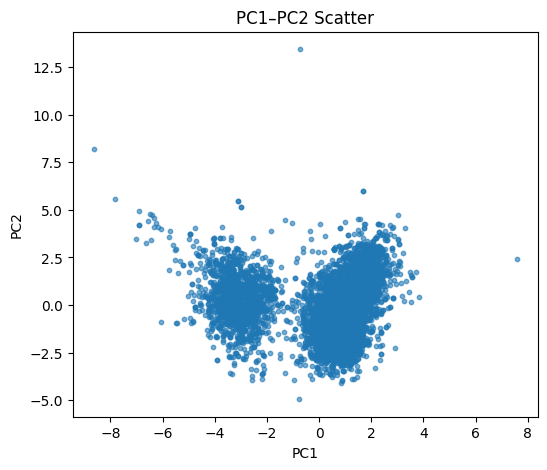

In [146]:
plt.figure(figsize=(6,5))
# s: size of the dot
# alpha: transparency
plt.scatter(X_pca[:,0], X_pca[:,1], s=10, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1–PC2 Scatter')
plt.show()

### Question: What seperate the clusters?

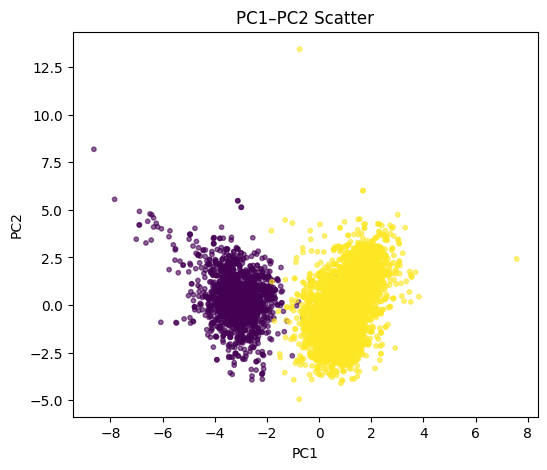

In [148]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=10, alpha=0.6, c=df['wine_type'].map({'red':0,'white':1}))
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1–PC2 Scatter')
plt.show()

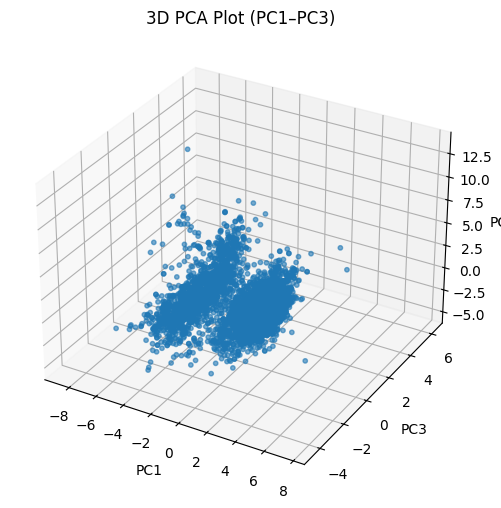

In [147]:
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,2], X_pca[:,1], s=10, alpha=0.6)

ax.set_xlabel('PC1')
ax.set_ylabel('PC3')
ax.set_zlabel('PC2')
ax.set_title('3D PCA Plot (PC1–PC3)')
plt.show()

### Part 4: K-means Clustering

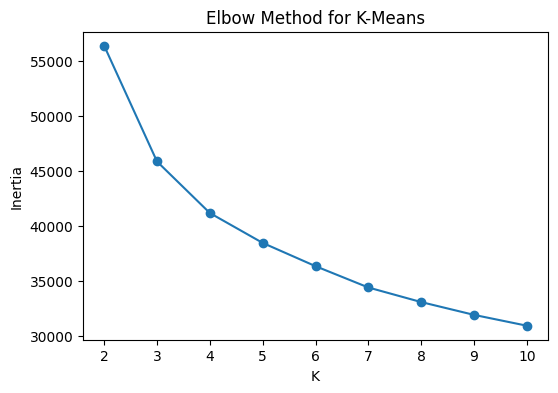

In [152]:
inertias = []
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=random_seed, n_init=20)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,11), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

In [174]:
K_star = 3
kmeans = KMeans(n_clusters=K_star, random_state=random_seed, n_init=20)
clusters = kmeans.fit_predict(X_scaled)
X['cluster'] = clusters
X['cluster'].value_counts()

cluster
1    3017
0    1889
2    1591
Name: count, dtype: int64

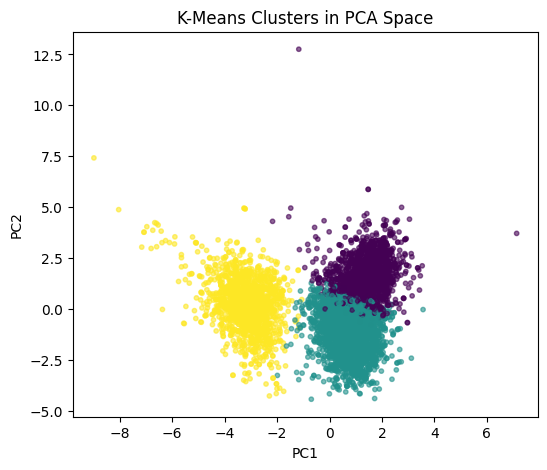

In [175]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=clusters, s=10, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters in PCA Space')
plt.show()

In [179]:
# Interpret clusters using raw variables
cluster_means = X.groupby('cluster').mean()
cluster_means

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,wine_type_white
cluster,,,,,,,,,,,,
0,6.976178,0.283134,0.358714,11.196030,0.053280,45.537586,169.913446,0.996988,3.155897,0.493510,9.541503,0.997882
1,6.774461,0.274266,0.319148,3.385863,0.040972,28.926748,118.589659,0.992164,3.208770,0.487315,11.130421,0.996354
2,8.335198,0.530805,0.270069,2.514299,0.087865,15.732558,46.034569,0.996778,3.311282,0.659447,10.409082,0.004400


## Part 5: Anomaly Detection

In [207]:
# train-val-test split
X_train, X_temp = train_test_split(X, test_size=0.4, random_state=random_seed)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=random_seed)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (3898, 12), Val shape: (1299, 12), Test shape: (1300, 12)


In [208]:
# standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [209]:
# fit a gaussian model on train only
mu = X_train_scaled.mean(axis=0)
Sigma_hat = np.cov(X_train_scaled, rowvar=False)

mvn = multivariate_normal(mean=mu, cov=Sigma_hat)
p_train = mvn.pdf(X_train_scaled)

# PCA for train
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

Threshold epsilon (1%): 6.2701e-15
Number of anomalies in Train: 39


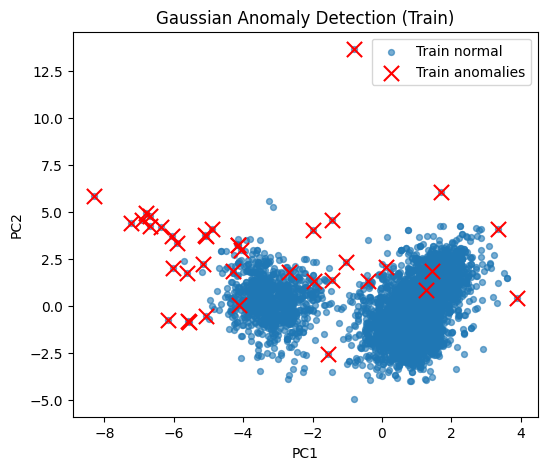

In [210]:
epsilon = np.percentile(p_train, 1)
print(f"Threshold epsilon (1%): {epsilon:.4e}")

is_anom_train = p_train < epsilon

print(f"Number of anomalies in Train: {np.sum(is_anom_train)}")

plt.figure(figsize=(6,5))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], s=18, alpha=0.6, label='Train normal')
plt.scatter(X_train_pca[is_anom_train,0], X_train_pca[is_anom_train,1], 
            marker='x', s=120, color='red', label='Train anomalies')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Gaussian Anomaly Detection (Train)')
plt.legend()
plt.show()

In [211]:
thresholds = [0.5, 1, 2]
results = []

for t in thresholds:
    eps = np.percentile(p_train, t)
    flagged_train = np.sum(p_train < eps)
    flagged_val = np.sum(p_val < eps)
    flagged_test = np.sum(p_test < eps)
    results.append({
        'Percentile': t,
        'Epsilon': eps,
        'Anomaly flagged': flagged_train
    })

results_df = pd.DataFrame(results)
print("\nSensitivity Analysis:")
print(results_df)


Sensitivity Analysis:
   Percentile       Epsilon  Anomaly flagged
0         0.5  1.262354e-18               20
1         1.0  6.270075e-15               39
2         2.0  7.266188e-12               78
